# AI Powered Road Damage Detection

## Data Preparation and Preprocessing

Imports

In [1]:
import os
import cv2
import glob
import random
import shutil
import xml.etree.ElementTree as ET

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm

import albumentations as A

from collections import Counter


Dataset Paths

In [2]:
DATASET_PATH = "India/train"

IMAGE_PATH = os.path.join(DATASET_PATH, "images")
ANNOTATION_PATH = os.path.join(DATASET_PATH, "annotations/xmls")

print("Images:", len(os.listdir(IMAGE_PATH)))
print("Annotations:", len(os.listdir(ANNOTATION_PATH)))

Images: 7706
Annotations: 7706


### EDA

Inspect Sample Images

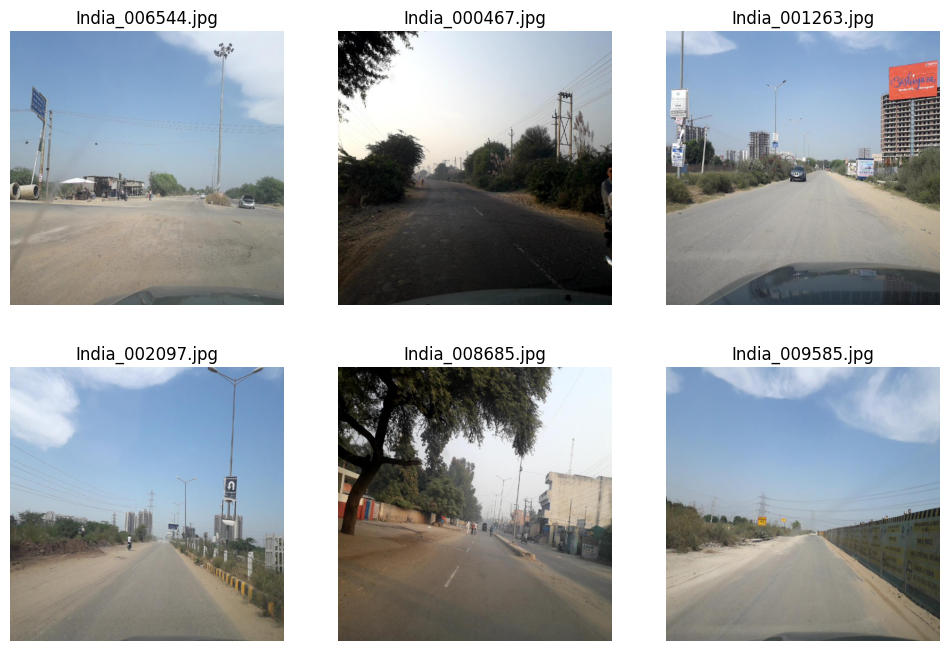

In [3]:
sample_images = random.sample(os.listdir(IMAGE_PATH), 6)

plt.figure(figsize=(12,8))

for i,img_name in enumerate(sample_images):
    
    img = cv2.imread(os.path.join(IMAGE_PATH,img_name))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(img_name)
    plt.axis("off")

plt.show()

Image Resolution Analysis

In [4]:
image_files = glob.glob(IMAGE_PATH+"/*.jpg")
annotation_files = glob.glob(ANNOTATION_PATH+"/*.xml")

widths=[]
heights=[]

for img_path in image_files[:1000]:

    img=cv2.imread(img_path)

    h,w,_=img.shape

    widths.append(w)
    heights.append(h)

print("Average Width:",np.mean(widths))
print("Average Height:",np.mean(heights))

Average Width: 720.0
Average Height: 720.0


Parse XML Annotations

In [5]:
def parse_annotation(xml_file):

    tree = ET.parse(xml_file)
    root = tree.getroot()

    boxes = []

    for obj in root.findall("object"):
        
        label = obj.find("name").text
        
        bbox = obj.find("bndbox")
        
        xmin = int(bbox.find("xmin").text)
        ymin = int(bbox.find("ymin").text)
        xmax = int(bbox.find("xmax").text)
        ymax = int(bbox.find("ymax").text)

        boxes.append([label, xmin, ymin, xmax, ymax])

    return boxes

Class Distribution

**Class Meanings:**
- D00: Longitudinal Crack (Linear cracks parallel to road direction)
- D01: Longitudinal Crack (Sealed/Repaired)
- D0w0: Longitudinal Crack (Wheelmark - rare variant)
- D10: Transverse Crack (Linear cracks perpendicular to road direction)
- D11: Transverse Crack (Sealed/Repaired)
- D20: Alligator/Crocodile Crack (Interconnected cracks forming patterns)
- D40: Pothole (Holes/depressions in pavement)
- D43: Cross Walk Blur (Faded crosswalk markings)
- D44: White Line Blur (Faded lane markings)
- D50: Other damage types

In [6]:
class_counts={}

for xml_file in tqdm(annotation_files):

    boxes=parse_annotation(xml_file)

    for b in boxes:

        label=b[0]

        if label in class_counts:
            class_counts[label]+=1
        else:
            class_counts[label]=1

print("Class Distribution:")
for label, count in class_counts.items():
    print(f"{label}: {count}")

100%|██████████| 7706/7706 [00:58<00:00, 132.34it/s]

Class Distribution:
D40: 3187
D44: 1062
D00: 1555
D20: 2021
D01: 179
D11: 45
D10: 68
D50: 28
D43: 57
D0w0: 1


Visualization of class distribution

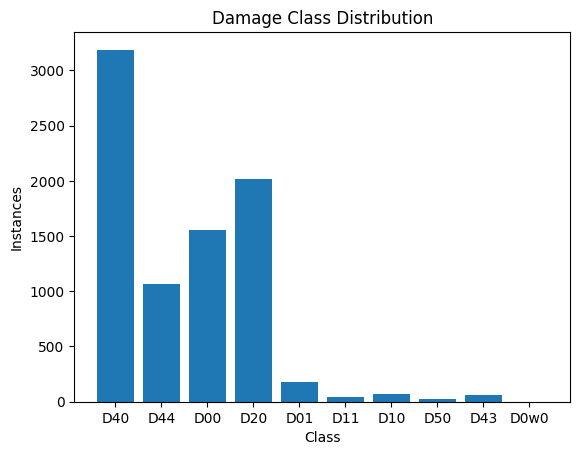

In [7]:
plt.bar(class_counts.keys(),class_counts.values())

plt.title("Damage Class Distribution")
plt.xlabel("Class")
plt.ylabel("Instances")

plt.show()

Bounding Box Size Distribution

In [8]:
areas=[]

for xml_file in annotation_files:

    boxes=parse_annotation(xml_file)

    for b in boxes:

        xmin,ymin,xmax,ymax=b[1:]

        area=(xmax-xmin)*(ymax-ymin)

        areas.append(area)

print("Average Area:",np.mean(areas))
print("Median Area:",np.median(areas))
print("Max Area:",np.max(areas))
print("Min Area:",np.min(areas))
print("Area Std Dev:",np.std(areas))

Average Area: 24218.12166280629
Median Area: 9856.0
Max Area: 346368
Min Area: 304
Area Std Dev: 33473.03338694723


Visualization of bounding box distribution

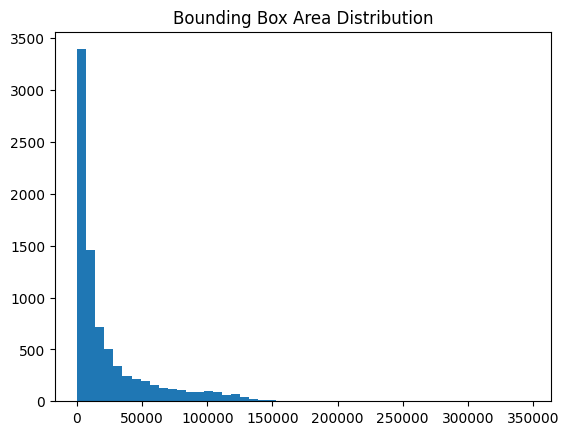

In [9]:
plt.hist(areas,bins=50)

plt.title("Bounding Box Area Distribution")

plt.show()

### Data Preparation

Filter Required Classes

In [10]:
CLASS_MAPPING = {
    "D00": "Longitudinal", "D01": "Longitudinal", "D0w0": "Longitudinal",
    "D10": "Transverse", "D11": "Transverse",
    "D20": "Alligator",
    "D40": "Pothole",
}

VALID_CLASSES = ["Longitudinal", "Transverse", "Alligator", "Pothole", "Others"]

def filter_boxes(boxes):
    filtered = []
    for b in boxes:
        mapped_class = CLASS_MAPPING.get(b[0], "Others")
        filtered.append([mapped_class] + b[1:])
    return filtered


In [11]:
classes_counts={}

for xml_file in tqdm(annotation_files):

    boxes=parse_annotation(xml_file)

    for b in boxes:

        label=b[0]
        
        mapping_class = CLASS_MAPPING.get(label, "Others")

        if mapping_class in classes_counts:
            classes_counts[mapping_class]+=1
        else:
                classes_counts[mapping_class]=1

print("Class Distribution after mapping:")
for label, count in classes_counts.items():
    print(f"{label}: {count}")

100%|██████████| 7706/7706 [00:00<00:00, 7707.64it/s]

Class Distribution after mapping:
Pothole: 3187
Others: 1147
Longitudinal: 1735
Alligator: 2021
Transverse: 113


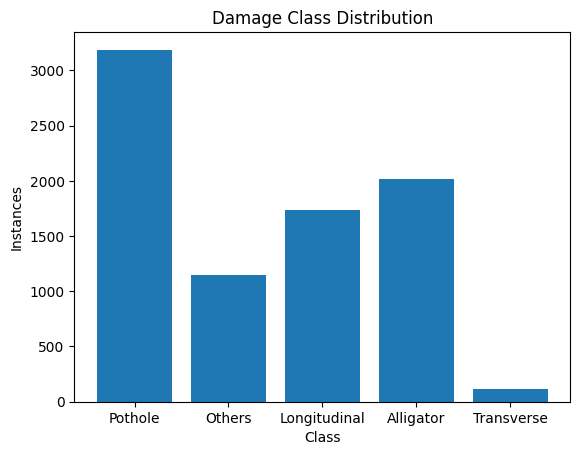

In [12]:
plt.bar(classes_counts.keys(),classes_counts.values())

plt.title("Damage Class Distribution")
plt.xlabel("Class")
plt.ylabel("Instances")

plt.show()

In [13]:
PROCESSED_PATH = "processed_data"
FINAL_DATASET = "final_dataset"

OLD_SIZE = 720
NEW_SIZE = 640
SCALE = NEW_SIZE / OLD_SIZE

CLASS_MAP = {
    'Pothole': 0,
    'Longitudinal': 1,
    'Alligator': 2,
    'Transverse': 3,
    'Others': 4
}

Output Folders

In [14]:
resized_img_path = os.path.join(PROCESSED_PATH, "resized_images")
resized_ann_path = os.path.join(PROCESSED_PATH, "resized_annotations")

balanced_img_path = os.path.join(PROCESSED_PATH, "balanced_images")
balanced_ann_path = os.path.join(PROCESSED_PATH, "balanced_annotations")

yolo_labels_path = os.path.join(PROCESSED_PATH, "yolo_labels")

for p in [resized_img_path,resized_ann_path,balanced_img_path,balanced_ann_path,yolo_labels_path]:
    os.makedirs(p, exist_ok=True)

Resized Image + XML function

In [15]:
def resize_image_and_annotation(img_file):

    img = cv2.imread(os.path.join(IMAGE_PATH, img_file))
    resized_img = cv2.resize(img,(NEW_SIZE,NEW_SIZE))

    cv2.imwrite(os.path.join(resized_img_path,img_file),resized_img)

    xml_file = os.path.splitext(img_file)[0]+".xml"
    xml_path = os.path.join(ANNOTATION_PATH,xml_file)

    if not os.path.exists(xml_path):
        return

    tree = ET.parse(xml_path)
    root = tree.getroot()

    for size in root.iter('size'):
        size.find('width').text=str(NEW_SIZE)
        size.find('height').text=str(NEW_SIZE)

    for obj in root.iter('object'):

        bbox=obj.find('bndbox')

        xmin=int(float(bbox.find('xmin').text)*SCALE)
        ymin=int(float(bbox.find('ymin').text)*SCALE)
        xmax=int(float(bbox.find('xmax').text)*SCALE)
        ymax=int(float(bbox.find('ymax').text)*SCALE)

        bbox.find('xmin').text=str(xmin)
        bbox.find('ymin').text=str(ymin)
        bbox.find('xmax').text=str(xmax)
        bbox.find('ymax').text=str(ymax)

    tree.write(os.path.join(resized_ann_path,xml_file))

Run Resized

In [16]:
image_files=os.listdir(IMAGE_PATH)

for img_file in tqdm(image_files):
    resize_image_and_annotation(img_file)

print("Resizing finished")

100%|██████████| 7706/7706 [01:40<00:00, 76.86it/s] 

Resizing finished


Augmentation Pipeline

In [17]:
transform=A.Compose(
[
A.HorizontalFlip(p=0.5),
A.VerticalFlip(p=0.3),
A.RandomBrightnessContrast(p=0.3),
A.Rotate(limit=20,p=0.5),
A.GaussNoise(p=0.2),
A.MotionBlur(p=0.2)
],
bbox_params=A.BboxParams(format='pascal_voc',label_fields=['labels'],min_visibility=0.3)
)

Augmentation Function

In [18]:
def augment_image(img_path,xml_path,save_id):

    img=cv2.imread(img_path)

    tree=ET.parse(xml_path)
    root=tree.getroot()

    boxes=[]
    labels=[]

    for obj in root.iter("object"):

        bbox=obj.find("bndbox")

        xmin=float(bbox.find("xmin").text)
        ymin=float(bbox.find("ymin").text)
        xmax=float(bbox.find("xmax").text)
        ymax=float(bbox.find("ymax").text)

        boxes.append([xmin,ymin,xmax,ymax])
        labels.append(obj.find("name").text)

    transformed=transform(image=img,bboxes=boxes,labels=labels)

    new_img=transformed["image"]
    new_boxes=transformed["bboxes"]

    base=os.path.splitext(os.path.basename(img_path))[0]

    new_img_name=f"{base}_aug{save_id}.jpg"
    new_xml_name=f"{base}_aug{save_id}.xml"

    cv2.imwrite(os.path.join(balanced_img_path,new_img_name),new_img)

    for obj,b in zip(root.iter("object"),new_boxes):

        bbox=obj.find("bndbox")

        bbox.find("xmin").text=str(int(b[0]))
        bbox.find("ymin").text=str(int(b[1]))
        bbox.find("xmax").text=str(int(b[2]))
        bbox.find("ymax").text=str(int(b[3]))

    tree.write(os.path.join(balanced_ann_path,new_xml_name))

In [ ]:
from collections import defaultdict

class_images = defaultdict(list)

for xml_file in tqdm(os.listdir(resized_ann_path)):

    xml_path = os.path.join(resized_ann_path, xml_file)
    img_name = xml_file.replace(".xml", ".jpg")
    img_path = os.path.join(resized_img_path, img_name)

    boxes = parse_annotation(xml_path)

    mapped_classes = set()

    for b in boxes:
        label = b[0]
        mapped = CLASS_MAPPING.get(label, "Others")
        mapped_classes.add(mapped)

    for cls in mapped_classes:
        class_images[cls].append((img_path, xml_path))


class_counts = {k: len(v) for k,v in class_images.items()}

print("Grouped Class Counts:")
for k,v in class_counts.items():
    print(k,":",v)

max_count = max(class_counts.values())

print("\nTarget count per class:", max_count)

100%|██████████| 7706/7706 [00:01<00:00, 7514.64it/s]

Grouped Class Counts:
Pothole : 1530
Others : 941
Longitudinal : 1218
Alligator : 1758
Transverse : 95

Target count per class: 1758


Number of augmentation required

In [20]:
aug_id = 0

for cls, items in class_images.items():

    current_count = len(items)
    needed = max_count - current_count

    print(f"\nClass {cls}: {current_count} -> Need {needed} augmentations")

    if needed <= 0:
        continue

    i = 0

    while needed > 0:

        img_path, xml_path = items[i % len(items)]

        augment_image(img_path, xml_path, aug_id)

        aug_id += 1
        needed -= 1
        i += 1


Class Pothole: 1530 -> Need 228 augmentations

Class Others: 941 -> Need 817 augmentations

Class Longitudinal: 1218 -> Need 540 augmentations

Class Alligator: 1758 -> Need 0 augmentations

Class Transverse: 95 -> Need 1663 augmentations


Copy files to balanced dataset

In [ ]:
for img in os.listdir(resized_img_path):

    shutil.copy(
        os.path.join(resized_img_path, img),
        os.path.join(balanced_img_path, img)
    )

for xml in os.listdir(resized_ann_path):

    shutil.copy(
        os.path.join(resized_ann_path, xml),
        os.path.join(balanced_ann_path, xml)
    )

print("Original files copied to balanced dataset")

Original files copied to balanced dataset


Convert Annotations (XML) to YOLO format

In [24]:
def xml_to_yolo(xml_file):

    tree=ET.parse(xml_file)
    root=tree.getroot()

    yolo_lines=[]

    for obj in root.iter("object"):

        cls=obj.find("name").text
        class_name=CLASS_MAPPING.get(cls,"Others")
        cls_id=CLASS_MAP[class_name]

        bbox=obj.find("bndbox")

        xmin=float(bbox.find("xmin").text)
        ymin=float(bbox.find("ymin").text)
        xmax=float(bbox.find("xmax").text)
        ymax=float(bbox.find("ymax").text)

        x_center=((xmin+xmax)/2)/NEW_SIZE
        y_center=((ymin+ymax)/2)/NEW_SIZE
        width=(xmax-xmin)/NEW_SIZE
        height=(ymax-ymin)/NEW_SIZE

        yolo_lines.append(
            f"{cls_id} {x_center} {y_center} {width} {height}"
        )

    return yolo_lines

Save YOLO labels

In [25]:
for xml in tqdm(os.listdir(balanced_ann_path)):

    xml_path=os.path.join(balanced_ann_path,xml)

    lines=xml_to_yolo(xml_path)

    txt=os.path.splitext(xml)[0]+".txt"

    with open(os.path.join(yolo_labels_path,txt),"w") as f:
        f.write("\n".join(lines))

100%|██████████| 10954/10954 [00:56<00:00, 195.18it/s]


Train / Validation Split

In [26]:
all_images=[f for f in os.listdir(balanced_img_path) if f.endswith(".jpg")]

random.shuffle(all_images)

split=int(0.8*len(all_images))

train=all_images[:split]
val=all_images[split:]

Create Final Dataset

In [27]:
train_img_dir=os.path.join(FINAL_DATASET,"images/train")
val_img_dir=os.path.join(FINAL_DATASET,"images/val")

train_lbl_dir=os.path.join(FINAL_DATASET,"labels/train")
val_lbl_dir=os.path.join(FINAL_DATASET,"labels/val")

for d in [train_img_dir,val_img_dir,train_lbl_dir,val_lbl_dir]:
    os.makedirs(d,exist_ok=True)

for img in tqdm(train):

    shutil.copy(os.path.join(balanced_img_path,img),train_img_dir)

    lbl=os.path.splitext(img)[0]+".txt"
    shutil.copy(os.path.join(yolo_labels_path,lbl),train_lbl_dir)

for img in tqdm(val):

    shutil.copy(os.path.join(balanced_img_path,img),val_img_dir)

    lbl=os.path.splitext(img)[0]+".txt"
    shutil.copy(os.path.join(yolo_labels_path,lbl),val_lbl_dir)

100%|██████████| 2191/2191 [00:20<00:00, 108.49it/s]


Create data.yaml

In [28]:
yaml=f"""
train: {os.path.abspath(train_img_dir)}
val: {os.path.abspath(val_img_dir)}

nc: 5
names: ['Pothole','Others','Longitudinal','Alligator','Transverse']
"""

with open(os.path.join(FINAL_DATASET,"data.yaml"),"w") as f:
    f.write(yaml)

print("Dataset ready")

Dataset ready


Visualization of Labels

In [20]:
def visualize(img_path,label_path):

    img = cv2.imread(img_path)
    h,w,_ = img.shape

    with open(label_path) as f:
        lines = f.readlines()

    for line in lines:

        cls,x,y,bw,bh = map(float,line.split())

        xmin = int((x - bw/2) * w)
        ymin = int((y - bh/2) * h)
        xmax = int((x + bw/2) * w)
        ymax = int((y + bh/2) * h)

        cv2.rectangle(img,(xmin,ymin),(xmax,ymax),(0,255,0),2)

    plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
    plt.axis("off")

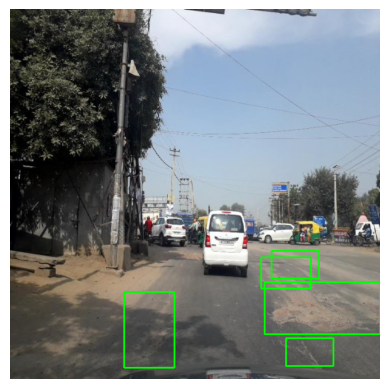

In [21]:
visualize('dataset/images/train/India_000057.jpg', 'dataset/labels/train/India_000057.txt')
plt.axis("off")
plt.show()
